# PS-S6E02: NN — Tabular ResNet (Embeddings)

This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

**Task**
*   Binary classification: predict **presence vs absence of heart disease**
*   Target column: Heart Disease
*   Evaluation metric: **ROC AUC**
*   Submission format: probability of disease presence per row
**Model**
*   Tabular neural network with:
    *   Numeric features
    *   Embedded categorical features
    *   Residual MLP backbone
*   Trained using stratified cross-validation
*   Final predictions are averaged across folds
  
This notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import gc
import sys
import copy
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_feature_engineering import FeatureFactory
from ps_s06e02_model_visualizer import ModelVisualizer
from ps_s06e02_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Heart Disease'

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

### Dataset Description
The dataset contains clinical and diagnostic measurements commonly used in heart disease screening.

**Key characteristics**
*   Mixed numeric and categorical inputs
*   Moderate dataset size (well-suited for NN + CV)
*   Target labels provided as strings:
    *   `Presence`
    *   `Absence`
  
**Target encoding**
*   `Presence` → 1
*   `Absence` → 0

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Feature Engineering Strategy
Feature engineering is intentionally conservative to preserve signal for the neural network.

### Applied strategies
*   **Drop ID and target**
    *   id and Heart Disease are removed from the feature matrix
*   **Standard scaling**
    *   Applied to numeric features only
*   **Feature interactions**
    *   Simple numeric interactions to capture non-linear effects
  
### Not applied
*   **One-hot encoding**
    *   Categorical variables are passed to the model as integer codes
    *   Embeddings are learned directly by the network
*   **Target transformations**
    *   Binary labels are used directly (no scaling or clipping)
  
This setup avoids destroying ordinal information and allows the NN to learn category relationships via embeddings.

In [6]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'interactions',      # Explicit interactions help convergence
    'standard_scaling',  # Ensures all features are on a comparable scale
]

In [7]:
print('Performing initial feature engineering.')

# Get a clean 0/1 label vector for AUC + BCE.
y = (
    training_df[TARGET]
    .map({'Absence': 0, 'Presence': 1})
    .astype(np.int64)
)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.copy()

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 14
New Feature Count: 18
     Age    Sex  Chest pain type     BP  Cholesterol  FBS over 120  \
0  0.468  0.632            0.807  1.436       -0.178        -0.295   
1 -0.259  0.632           -2.716 -0.367        2.375        -0.295   
2  0.226 -1.583           -1.541  1.970       -1.693        -0.295   
3 -1.228 -1.583           -0.367  0.234       -0.475        -0.295   
4  0.468  0.632            0.807  0.635       -0.327        -0.295   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0       -0.983   0.271            1.629          3.041        0.998   
1        1.020   0.951           -0.614         -0.755       -0.836   
2        1.020  -0.095           -0.614         -0.755       -0.836   
3        1.020  -0.147           -0.614          0.299        0.998   
4        1.020  -1.455            1.629          3.252        0.998   

   Number of vessels fluro  Thallium  Theoretical_Max_HR  HR_Deficie

### Model Training: Neural Network Strategy (Binary Classification)

Model training is performed using **5-Fold Stratified Cross-Validation**, which is critical for stabilizing neural network performance on a binary classification task with class imbalance.

Neural networks are sensitive to random initialization, learning-rate schedules, and training duration. Cross-validation combined with early stopping provides a more reliable estimate of generalization performance and reduces the risk of overfitting.
1.  **Feature Scaling and Input Preparation**
    * **Numeric features** are standardized prior to training to ensure comparable scales across inputs.
    * **Categorical features** are passed as integer-encoded values and learned via embedding layers inside the model.
    * The target variable is encoded as:
        * `Presence → 1`
        * `Absense → 0`
    * Standardizing numeric inputs improves optimizer stability and convergence when training with gradient-based methods.
2.  **Stratified Cross-Validation**
    * Training uses **StratifiedKFold** to preserve class proportions in every fold.
    * This is especially important for ROC AUC evaluation, which can be sensitive to skewed validation splits.
    * Out-of-fold probability estimates are stored for unbiased evaluation and later blending.
3.  **Optimization Objective**
    * The model is trained using **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`).
    * The network outputs raw logits; the sigmoid function is applied only during evaluation to produce probabilities.
    * Model performance is evaluated using **ROC AUC**, matching the competition’s leaderboard metric.
4.  **Adaptive Learning and Early Stopping**
To prevent overfitting and unnecessary training:
    * **ReduceLROnPlateau** lowers the learning rate when validation AUC plateaus.
    * **Early stopping** is applied based on validation AUC.
    * For each fold, the model weights corresponding to the best validation AUC are restored before inference.
  
This approach ensures that each fold contributes well-calibrated probability estimates rather than over-trained predictions.

In [8]:
def prepare_inputs_for_nn(X_train, X_test, cat_features):
    """
    Separates data into Numerical (float) and Categorical (int) parts.
    Label Encodes categoricals to [0, N-1] for embeddings.
    """
    # Identify Numeric vs Categorical columns
    # We exclude the target 'exam_score' from this logic
    all_cols = X_train.columns.tolist()
    num_cols = [c for c in all_cols if c not in cat_features]
    
    X_train_cat = X_train[cat_features].copy()
    X_test_cat = X_test[cat_features].copy()
    
    # Label Encode Categoricals safely (Handle new categories in test)
    cat_dims = [] # Tuples of (num_unique, embedding_size)
    
    for col in cat_features:
        # Fill NaNs with a string "MISSING" to treat it as a category
        X_train_cat[col] = X_train_cat[col].astype(str).fillna('MISSING')
        X_test_cat[col] = X_test_cat[col].astype(str).fillna('MISSING')
        
        le = LabelEncoder()
        # Fit on both to ensure we capture all categories
        unique_vals = pd.concat([X_train_cat[col], X_test_cat[col]]).unique()
        le.fit(unique_vals)
        
        # Transform
        X_train_cat[col] = le.transform(X_train_cat[col])
        X_test_cat[col] = le.transform(X_test_cat[col])
        
        # Determine Embedding Size (Rule of thumb: min(50, (num_categories + 1) // 2))
        num_cats = len(unique_vals)
        emb_dim = min(50, (num_cats + 1) // 2)
        cat_dims.append((num_cats, emb_dim))
        
    # Prepare Numerics (Already Gaussian'd by FeatureFactory, just fill NaNs)
    X_train_num = X_train[num_cols].fillna(0).values
    X_test_num = X_test[num_cols].fillna(0).values
    
    return {
        'train_cat': X_train_cat.values.astype(np.int64),
        'train_num': X_train_num.astype(np.float32),
        'test_cat': X_test_cat.values.astype(np.int64),
        'test_num': X_test_num.astype(np.float32),
        'cat_dims': cat_dims,
        'num_dim': len(num_cols)
    }

### Categorical Features
The following columns are treated as categorical and embedded by the model:
*   `Sex`
*   `Chest pain type`
*   `FBS over 120`
*   `EKG results`
*   `Exercise angina`
*   `Slope of ST`
*   `Number of vessels fluro`
*   `Thallium`
  
All remaining features are treated as continuous numeric inputs.

In [9]:
# Identify categorical features manually (TODO: via helper?)
cat_cols = [
    'Sex',
    'Chest pain type',
    'FBS over 120',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium',
]

# Ensure these exist in X_full (FeatureFactory might rename/drop them)
valid_cats = [c for c in cat_cols if c in X.columns]

data_package = prepare_inputs_for_nn(X, X_test, valid_cats)

In [10]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, hidden_dim=512, dropout_rate=0.2, num_blocks=3):
        super(TabularResNet, self).__init__()
        
        # Embedding Layers for Categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim) 
            for num_cats, emb_dim in cat_dims
        ])
        
        # Calculate total input size after embeddings
        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim
        
        # Input Projector
        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)
        
        # Residual Blocks
        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Output Head
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat):
        # x_num: [batch_size, num_dim]
        # x_cat: [batch_size, num_cats] (Integers)
        
        # Process Embeddings
        embedded_cats = []
        for i, emb_layer in enumerate(self.embeddings):
            # x_cat[:, i] grabs the column for the i-th categorical var
            embedded_cats.append(emb_layer(x_cat[:, i]))
        
        # Concatenate all embeddings + numericals
        # [batch, cat_dim_1] + [batch, cat_dim_2] ... + [batch, num_dim]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        
        # Pass through network
        x = self.input_layer(x)
        x = self.bn0(x)
        
        for block in self.blocks:
            x = block(x)
            
        return self.output_head(x)

In [11]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.01
DROPOUT_RATE = 0.2

Training on: cuda


In [12]:
# Dataset Class to handle Dual Inputs
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        self.y = torch.FloatTensor(y).reshape(-1, 1) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

### Evaluation Metric
**Primary metric: ROC AUC**
*   Computed on:
    *   Each validation fold
    *   Final out-of-fold predictions
*   Uses **predicted probabilities**, not hard labels
  
**Why AUC**
*   Threshold-independent
*   Robust to class imbalance
*   Matches Kaggle leaderboard scoring

In [13]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 512
EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Training Setup
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

oof_probs = np.zeros(len(X))
test_probs = np.zeros(len(X_test))
history = {'train_loss': [], 'val_auc': [], 'lrs': []}
scores = []

print(f'Starting Training with {n_folds} folds...')

# Pre-convert test data to tensors to save time in the loop
# We chunk this if memory is an issue, but for this size, it's usually fine
X_test_cat_tensor = torch.LongTensor(data_package['test_cat']).to(device)
X_test_num_tensor = torch.FloatTensor(data_package['test_num']).to(device)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    gc.collect()
    print(f'\n=== Fold {fold+1} ===')

    # Slice the pre-prepared numpy arrays
    X_train_cat_fold = data_package['train_cat'][train_idx]
    X_val_cat_fold   = data_package['train_cat'][val_idx]
    
    X_train_num_fold = data_package['train_num'][train_idx]
    X_val_num_fold   = data_package['train_num'][val_idx]
    
    y_train_fold = y.iloc[train_idx].values.astype(np.float32)
    y_val_fold   = y.iloc[val_idx].values.astype(np.float32)
    
    # Datasets & Loaders
    train_ds = TabularDataset(X_train_num_fold, X_train_cat_fold, y_train_fold)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # Prepare Validation Tensors (Full batch for fast inference)
    # Moving full validation set to GPU for speed (dataset is small enough)
    val_num_t = torch.FloatTensor(X_val_num_fold).to(device)
    val_cat_t = torch.LongTensor(X_val_cat_fold).to(device)    
    
    # Model Init
    model = TabularResNet(
        num_dim=data_package['num_dim'], 
        cat_dims=data_package['cat_dims']
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()

    # SCHEDULER: Using CosineAnnealingWarmRestarts
    # T_0=10 means it resets LR every 10 epochs
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    # Early Stopping / Best Model Logic
    best_val_auc = -float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    ES_PATIENCE = 15
    
    progress_bar = tqdm(range(EPOCHS), desc=f'Fold {fold+1}', leave=True)

    # Outer Loop: Epochs
    for epoch in progress_bar:
        model.train()
        running_loss = 0.0

        for batch_num, batch_cat, batch_y in train_loader:
            batch_num, batch_cat, batch_y = batch_num.to(device), batch_cat.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            # Pass both inputs
            probs = model(batch_num, batch_cat)
            loss = criterion(probs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Step Scheduler (Cosine updates every batch usually, but epoch is fine for tabular)
        scheduler.step()
        
        # Validation Check (End of Epoch)
        model.eval()

        with torch.no_grad():
            val_logits = model(val_num_t, val_cat_t).detach().cpu().numpy().ravel()
            
            # Sigmoid
            val_prob = 1.0 / (1.0 + np.exp(-val_logits))
            val_auc = roc_auc_score(y_val_fold, val_prob)

        history['train_loss'].append(running_loss / len(train_loader))
        history['val_auc'].append(val_auc)
        history['lrs'].append(optimizer.param_groups[0]['lr'])

        # Save Best Model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        # Update Progress Bar Text
        progress_bar.set_postfix({
            'loss': f'{running_loss/len(train_loader):.4f}',
            'val_auc': f'{val_auc:.4f}',
            'best': f'{best_val_auc:.4f}'
        })
        
        if patience_counter >= ES_PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    # Final Inference for Fold using Best Weights
    model.load_state_dict(best_model_weights)
    model.eval()
    with torch.no_grad():
        val_logits = model(val_num_t, val_cat_t).detach().cpu().numpy().ravel()
        val_prob = 1.0 / (1.0 + np.exp(-val_logits))
        oof_probs[val_idx] = val_prob
        
        test_logits = model(X_test_num_tensor, X_test_cat_tensor).detach().cpu().numpy().ravel()
        test_prob = 1.0 / (1.0 + np.exp(-test_logits))
        test_probs += test_prob / n_folds

    print(f'Fold {fold+1} Best AUC: {best_val_auc:.5f}')
    scores.append(best_val_auc)
    
print(f'\nOverall CV AUC: {np.mean(scores):.5f}')        

Training on: cuda
Starting Training with 5 folds...

=== Fold 1 ===


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 45
Fold 1 Best AUC: 0.95392

=== Fold 2 ===


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 25
Fold 2 Best AUC: 0.95302

=== Fold 3 ===


...

  Early stopping at epoch 25
Fold 3 Best AUC: 0.95270

=== Fold 4 ===


Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 25
Fold 4 Best AUC: 0.95356

=== Fold 5 ===


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 25
Fold 5 Best AUC: 0.95246

Overall CV AUC: 0.95313


## Visualizing Model Performance
The following diagnostics are generated using out-of-fold predictions:
* ROC curve
* Training heartbeat
* Distribution mismatch
* Normalized confusion matrix (at 0.5 threshold)

<Figure size 800x600 with 0 Axes>

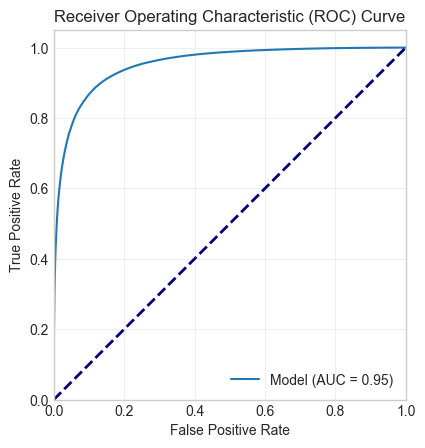

In [14]:
mviz = ModelVisualizer(model_name='Neural Network')

mviz.plot_roc_curve(y_true=y.values, y_score=oof_probs)

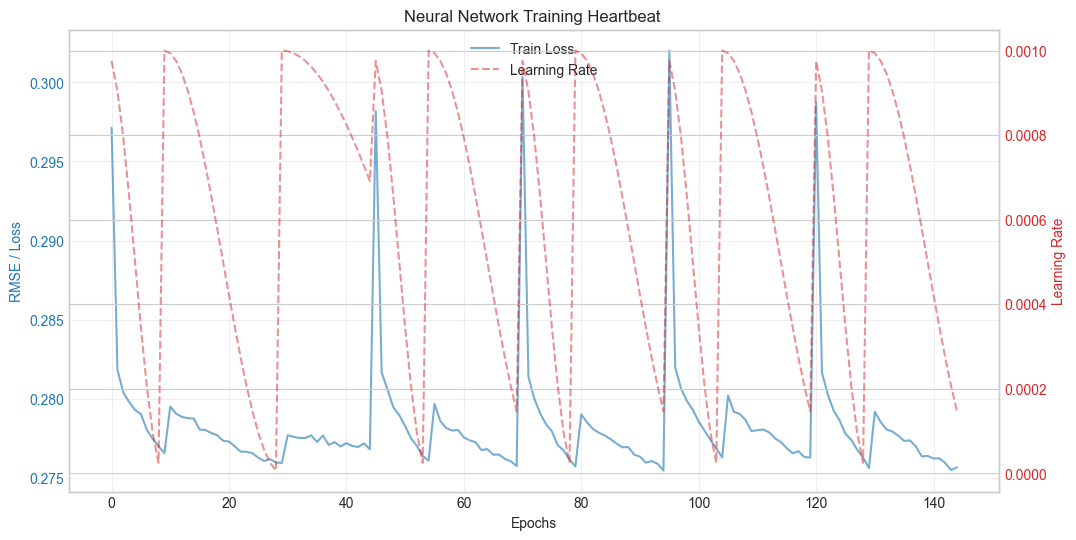

In [15]:
mviz.plot_training_heartbeat(history)

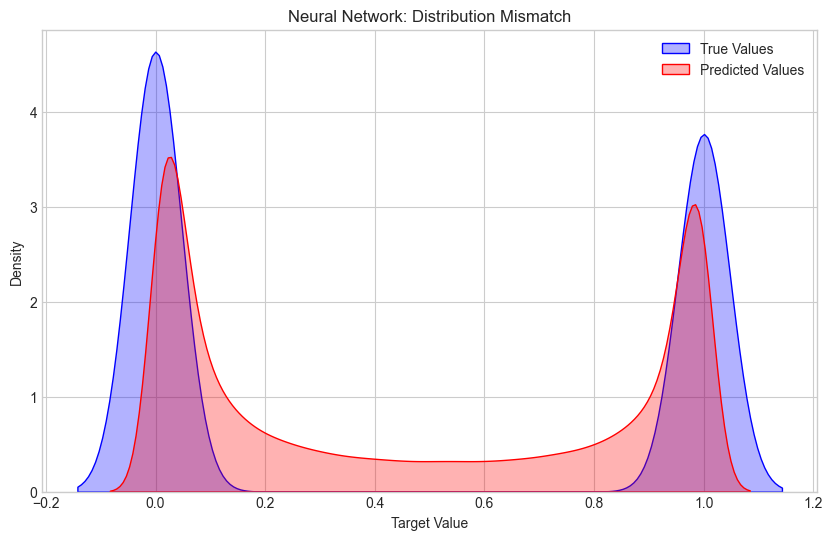

In [16]:
mviz.plot_distribution_mismatch(y_val_fold, oof_probs) # Use the last fold's data

Normalized confusion matrix


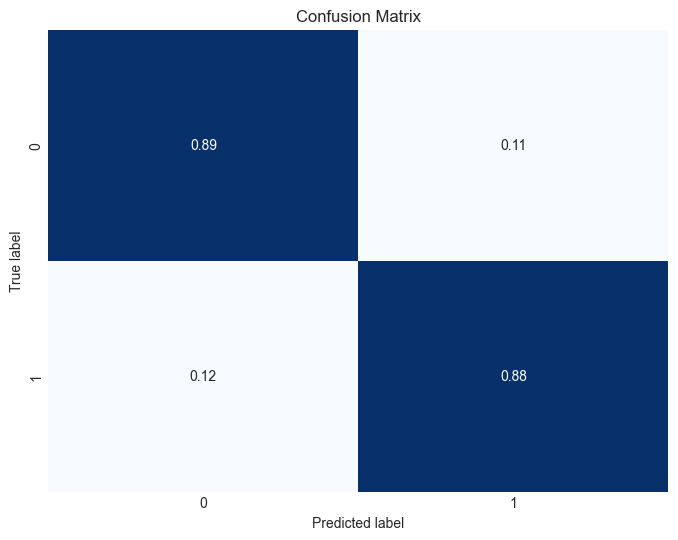

In [17]:
prob_label = (oof_probs >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y.values, y_pred=prob_label, classes=[0, 1], normalize=True)

## Prepare Submission

In [18]:
submission_df = helper.read_dataset('submission')
target_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[target_col] = test_probs

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  Heart Disease
0  630000          0.929
1  630001          0.005
2  630002          0.990
3  630003          0.005
4  630004          0.362
5  630005          0.990
6  630006          0.028
7  630007          0.701
8  630008          0.996
9  630009          0.014


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) **probability estimates** and averaged test-set **probability estimates**
are saved for downstream analysis and ensembling.

These files are used to:

- Compare model performance using OOF ROC AUC
- Analyze correlation and complementarity between models
- Serve as inputs to a separate blending notebook that combines model probabilities

Each file contains raw, un-thresholded probabilities, which is essential for
AUC-based evaluation and weighted blending techniques, including those described by
Tilii in *For the (recovering) blind blending addicts*:
https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787


In [20]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF probabilities and raw Test probabilities.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'],
    'prob_nn_tabular_resnet': oof_probs,
    'target': y.values
})
oof_df.to_csv(f'{output_dir}/nn-tabular-resnet_oof_probs.csv', index=False)

test_prob_df = pd.DataFrame({
    'id': test_df['id'],
    'prob_nn_tabular_resnet': test_probs
})
test_prob_df.to_csv(f'{output_dir}/nn-tabular-resnet_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/nn-tabular-resnet_oof_probs.csv, {output_dir}/nn-tabular-resnet_test_probs.csv')

Saved for Blending: predictions/nn-tabular-resnet_oof_probs.csv, predictions/nn-tabular-resnet_test_probs.csv
